## Coursework 2 Group (text)

Group number: 29

Student names and k-numbers:
1. Kishan Bangsi Magar - K2545729
2. Pradeep Appasaheb Nayak - K2520606
3. Shweta Patankar - K2557766
4. Daniel Rolon Rodriguez - K2552225

# Load modules (code)

## Environment detection

In [1]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

print("Running in Colab:", IN_COLAB)
print("Colab push")

Running in Colab: False
Colab push


## Module importing

In [2]:
# Install dependencies
if IN_COLAB:
    import sys
    !git clone https://github.com/4yala/NotebooksDL
    %cd NotebooksDL
    !{sys.executable} -m pip install -r requirements.txt
import os

#Deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam

#Data handling
import numpy as np
import random
import math

# Dataset
import medmnist
from medmnist import INFO
from medmnist.dataset import OrganSMNIST

# Pre-processing / Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Evaluation
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
        ConfusionMatrixDisplay, balanced_accuracy_score,
        roc_auc_score, roc_curve, auc)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

2026-04-10 23:34:49.882576: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-10 23:34:50.542848: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-10 23:34:50.825736: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-10 23:34:50.904632: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-10 23:34:51.265321: I tensorflow/core/platform/cpu_feature_guar

## Preparation

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError:
        pass

I0000 00:00:1775864098.594481  771632 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775864098.948182  771632 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775864098.948223  771632 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


# Load data

In [4]:
#Dataset selection
data_flag = "organsmnist"
info = INFO[data_flag]
data_root = "./data"

#Dataset loading
train_dataset = OrganSMNIST(split="train", download=True, size=224, root=data_root)
val_dataset   = OrganSMNIST(split="val", download=True, size=224, root=data_root)
test_dataset  = OrganSMNIST(split="test", download=True, size=224, root=data_root)

#NumPy formatting
X_train, y_train = train_dataset.imgs, train_dataset.labels
X_val, y_val     = val_dataset.imgs, val_dataset.labels
X_test, y_test   = test_dataset.imgs, test_dataset.labels

#Labelling
classes = np.unique(y_train)
num_classes = len(classes)
class_names = list(info["label"].values())


## Preprocess data

In [5]:
#Normalise data
X_train_normal = X_train / 255.0
X_val_normal   = X_val / 255.0
X_test_normal  = X_test / 255.0

#Flatten data
X_train_flat = X_train_normal.reshape(len(X_train_normal), -1)
X_val_flat   = X_val_normal.reshape(len(X_val_normal), -1)
X_test_flat  = X_test_normal.reshape(len(X_test_normal), -1)

# Initial Visualisation

## Basic observations

In [7]:
#Dataset shape checks
print("Train shape:")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nValidation shape:")
print("X:", X_val.shape)
print("y:", y_val.shape)

print("\nTest shape:")
print("X:", X_test.shape)
print("y:", y_test.shape)

#Label visualisation
print("\nNumber of classes:", len(info["label"]))
print("Class labels:")
for idx, name in info["label"].items():
    print(f"{idx}: {name}")

Train shape:
X: (13932, 224, 224)
y: (13932, 1)

Validation shape:
X: (2452, 224, 224)
y: (2452, 1)

Test shape:
X: (8827, 224, 224)
y: (8827, 1)

Number of classes: 11
Class labels:
0: bladder
1: femur-left
2: femur-right
3: heart
4: kidney-left
5: kidney-right
6: liver
7: lung-left
8: lung-right
9: pancreas
10: spleen


## Class balance observation

### Setup

In [ ]:
def get_class_counts(labels, num_classes):
    counts = np.zeros(num_classes)

    # labels often come as shape (N, 1)
    labels = np.squeeze(labels)

    for l in labels:
        counts[int(l)] += 1

    return counts

def plot_histogram(counts, title):
    plt.figure(figsize=(10,5))
    plt.bar(class_names, counts)
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.ylabel("Number of samples")
    plt.tight_layout()
    print("\n")
    plt.show()

def plot_pie(counts, title):
    plt.figure(figsize=(8,8))
    colours = plt.cm.tab20(np.linspace(0, 1, len(counts)))
    plt.pie(counts, labels=class_names, autopct='%1.1f%%', colors=colours)
    plt.title(title)
    print("\n")
    plt.show()

### Train split

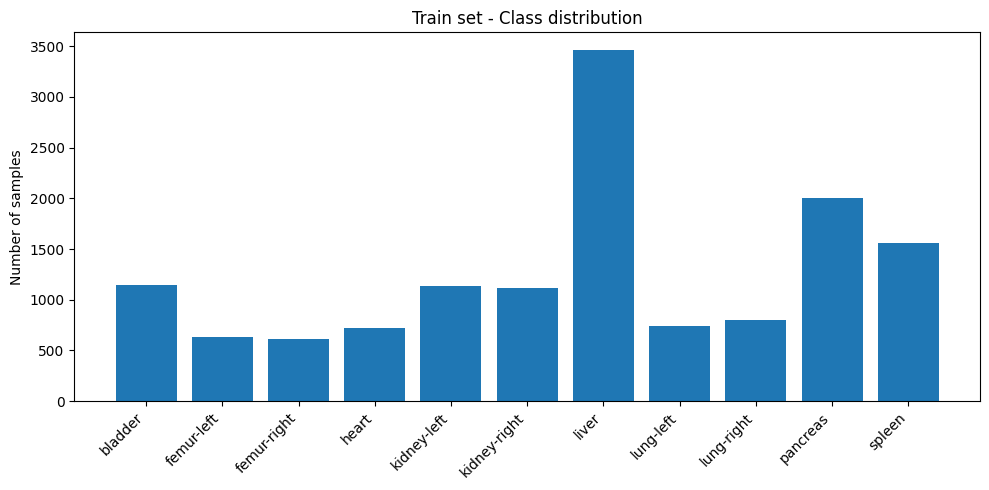

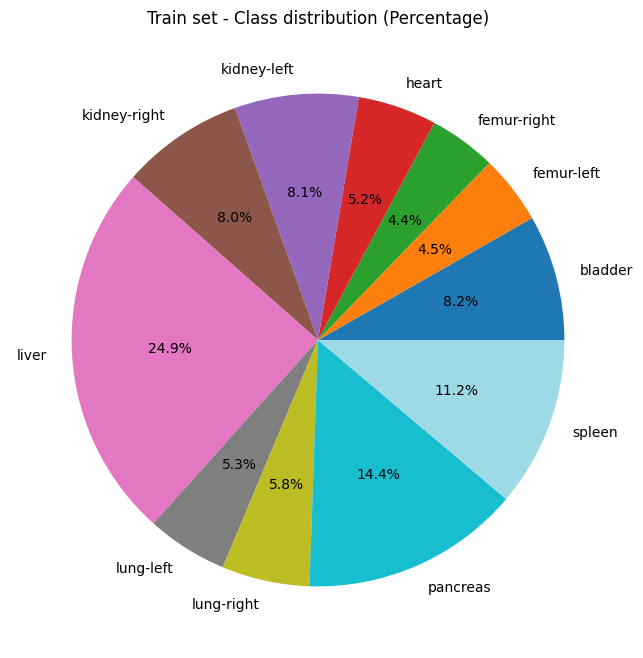

In [ ]:
train_counts = get_class_counts(y_train, num_classes)
plot_histogram(train_counts, "Train set - Class distribution")
plot_pie(train_counts, "Train set - Class distribution (Percentage)")

### Validation split


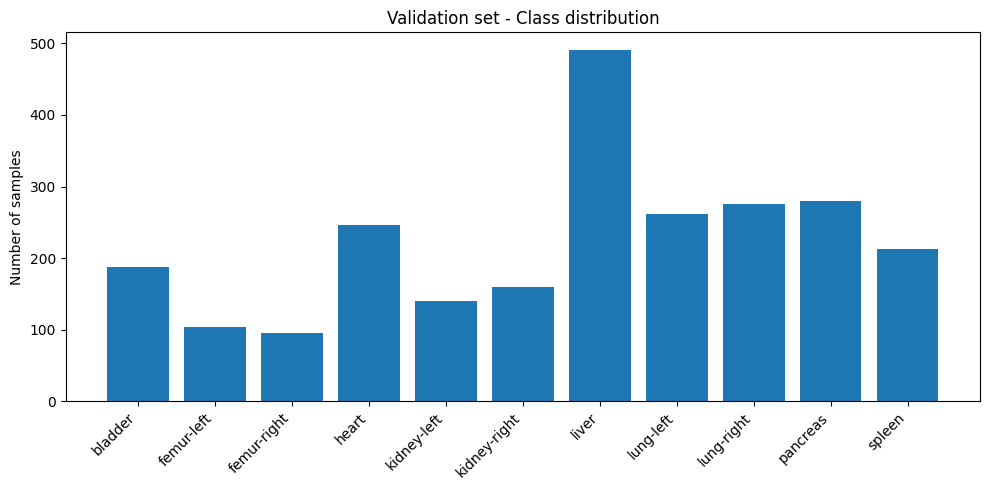

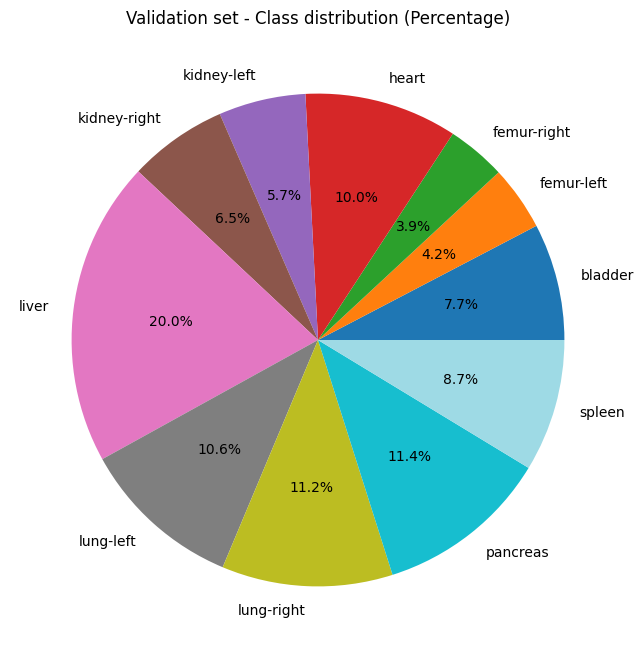

In [ ]:
val_counts   = get_class_counts(y_val, num_classes)
plot_histogram(val_counts, "Validation set - Class distribution")
plot_pie(val_counts, "Validation set - Class distribution (Percentage)")


### Test split

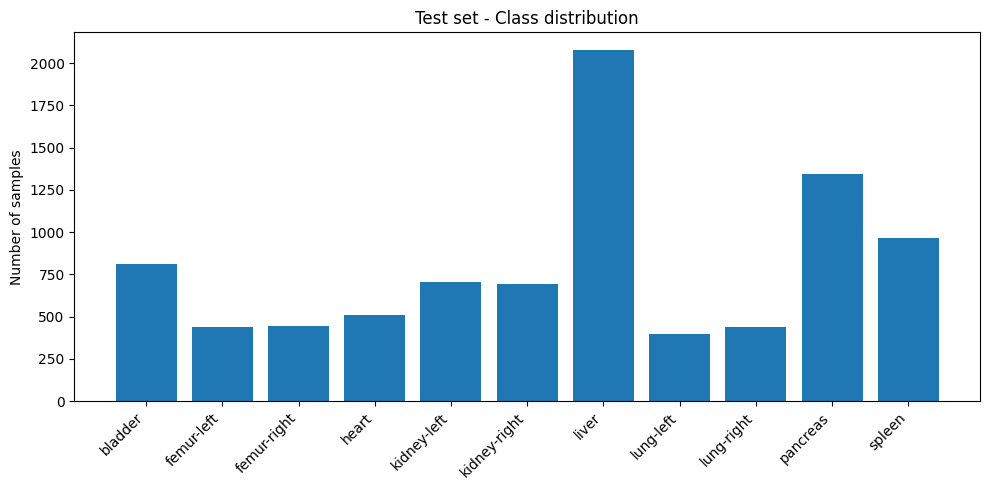

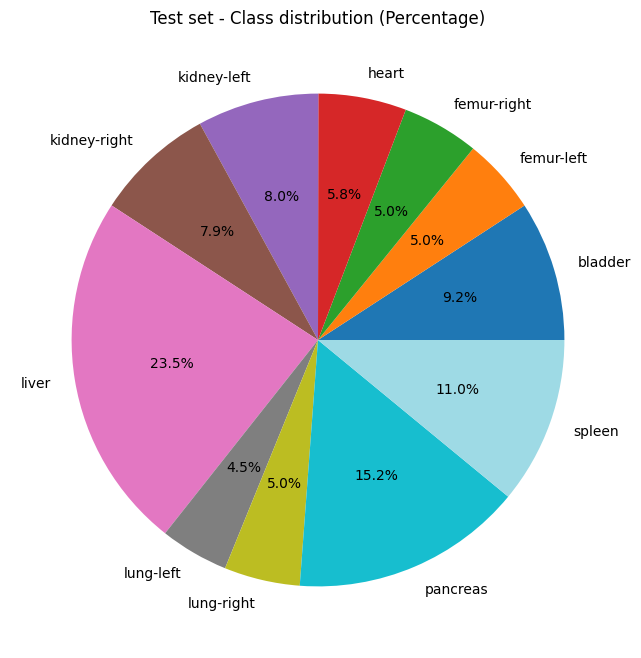

In [ ]:
test_counts  = get_class_counts(y_test, num_classes)
plot_histogram(test_counts, "Test set - Class distribution")
plot_pie(test_counts, "Test set - Class distribution (Percentage)")

### Split comparison

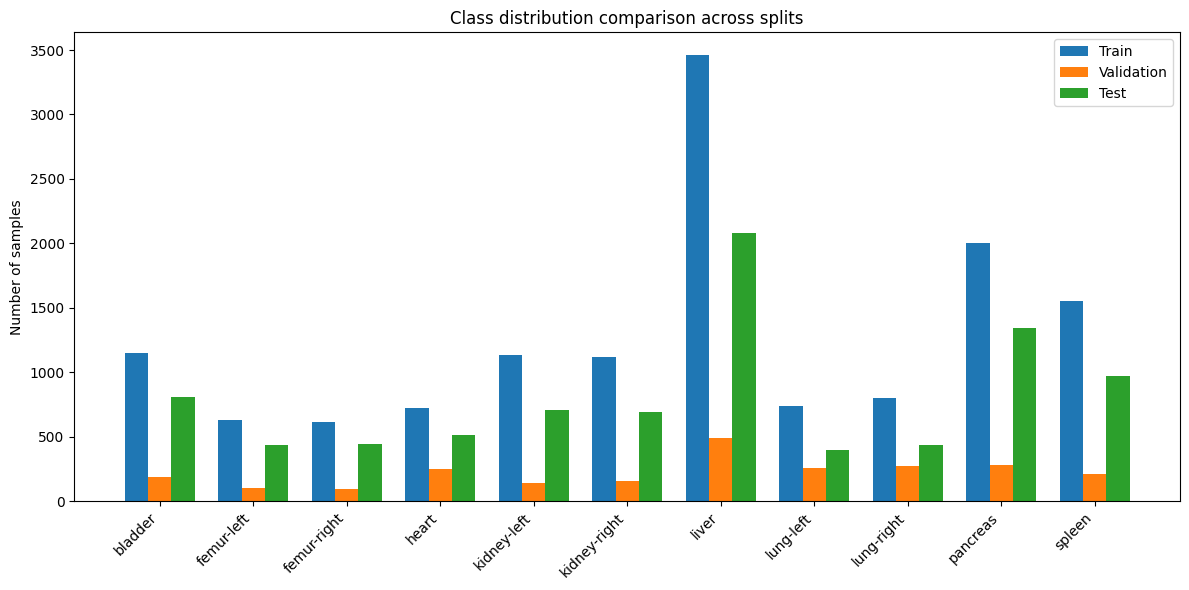

In [ ]:
x = np.arange(num_classes)
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, train_counts, width, label='Train')
plt.bar(x, val_counts, width, label='Validation')
plt.bar(x + width, test_counts, width, label='Test')

plt.xticks(x, class_names, rotation=45, ha='right')
plt.title("Class distribution comparison across splits")
plt.ylabel("Number of samples")
plt.legend()
plt.tight_layout()
plt.show()

## Sample visualisation

### Setup

In [ ]:
def show_images(images, labels, title, class_names, n=None):
    if n is None:
        n = len(images)

    cols = 3
    rows = math.ceil(n / cols)

    plt.figure(figsize=(6, 2 * rows))

    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(class_names[int(labels[i])])
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_one_per_class(X, y, title):
    seen = {}
    images = []
    labels = []

    y = np.squeeze(y)

    for img, label in zip(X, y):
        label = int(label)

        if label not in seen:
            seen[label] = True
            images.append(img)
            labels.append(label)

        if len(seen) == len(class_names):
            break

    show_images(images, labels, title, class_names, n=len(class_names))

def show_samples_per_class(X, y, class_names, samples_per_class=5):
    y = np.squeeze(y)

    num_classes = len(class_names)

    for cls in range(num_classes):

        # get all images of this class
        idx = np.where(y == cls)[0]

        # handle edge case
        if len(idx) == 0:
            continue

        # randomly sample from this class
        chosen = np.random.choice(idx,
                                   size=min(samples_per_class, len(idx)),
                                   replace=False)

        images = X[chosen]
        labels = y[chosen]

        # plot grid
        cols = samples_per_class
        rows = 1

        plt.figure(figsize=(2 * cols, 2))

        for i in range(len(images)):
            plt.subplot(rows, cols, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.title(class_names[int(labels[i])], fontsize=8)
            plt.axis('off')

        plt.suptitle(f"Class {cls}: {class_names[cls]}", fontsize=12)
        plt.tight_layout()
        plt.show()

### Random samples

/tmp/ipykernel_9642/2522428795.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(labels[i])])


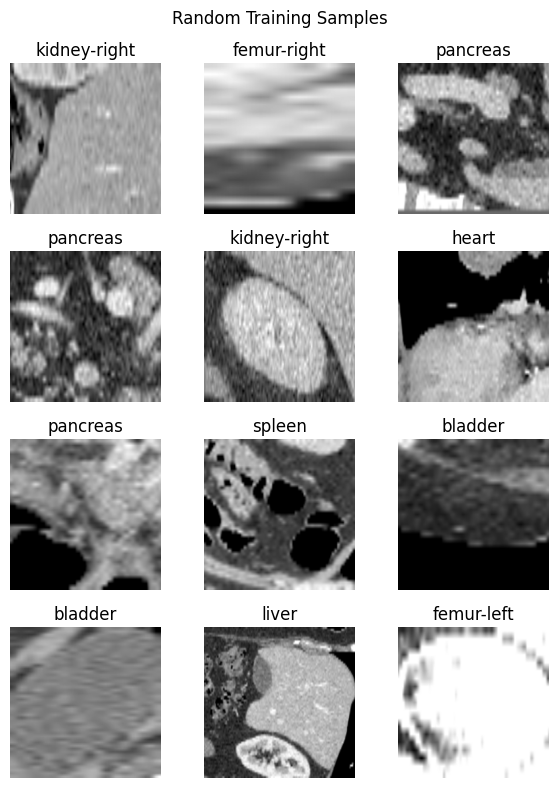

In [ ]:
idx = np.random.choice(len(X_train), 12, replace=False)

show_images(
    X_train[idx],
    y_train[idx],
    "Random Training Samples",
    class_names
)

### One per class

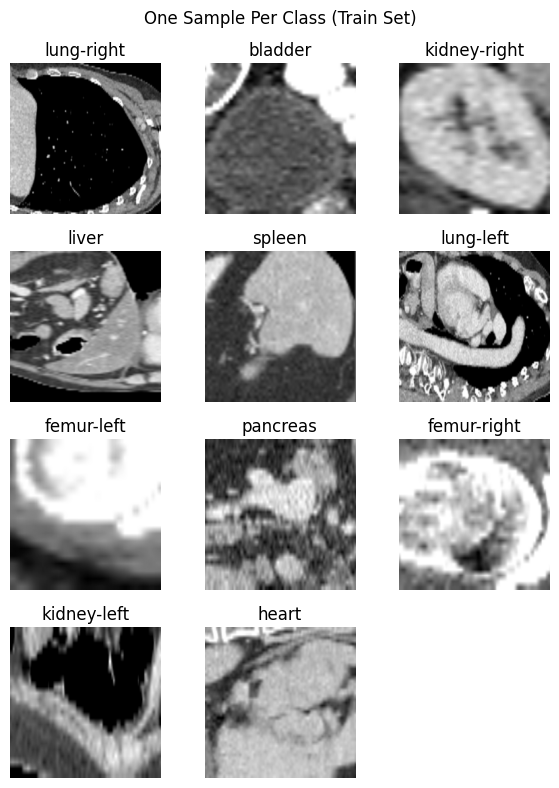

In [ ]:
show_one_per_class(X_train, y_train, "One Sample Per Class (Train Set)")

### Random per class

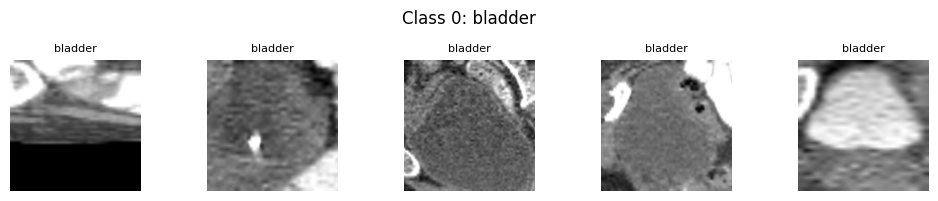

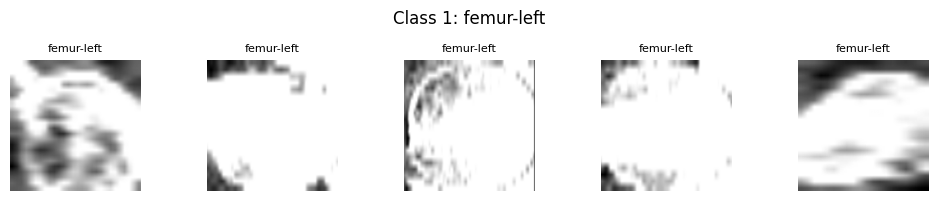

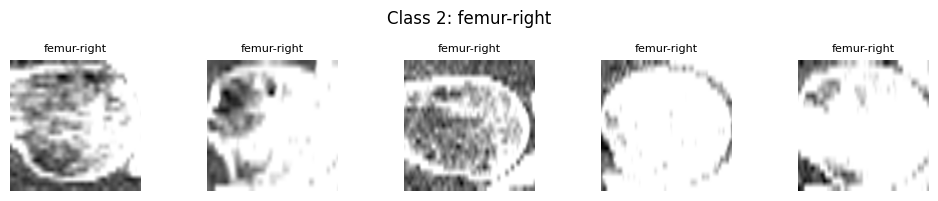

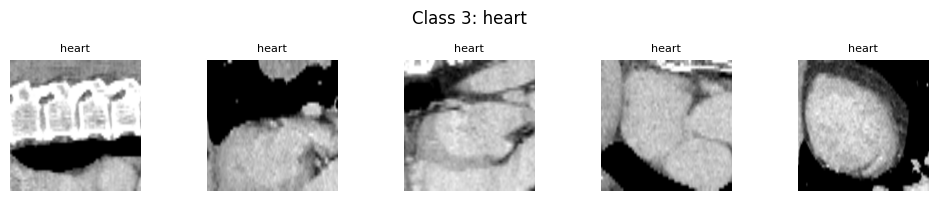

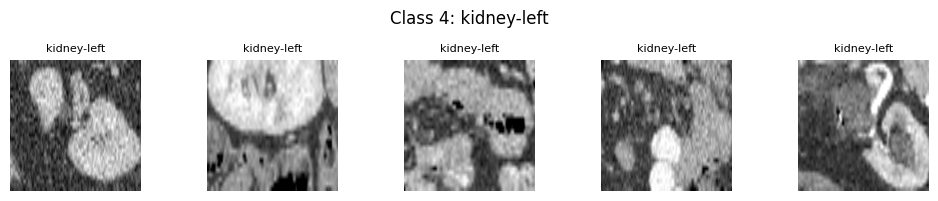

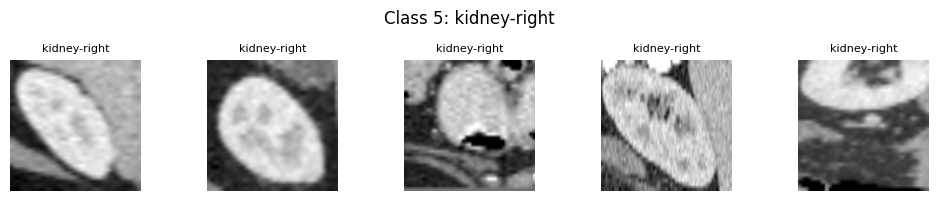

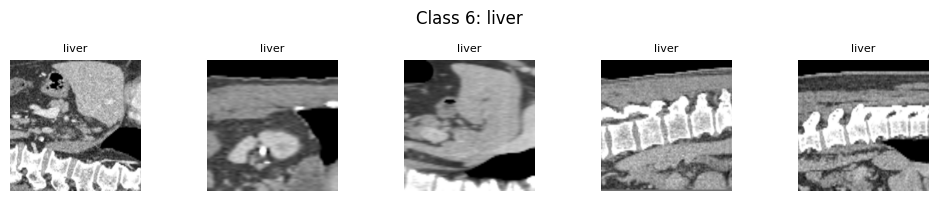

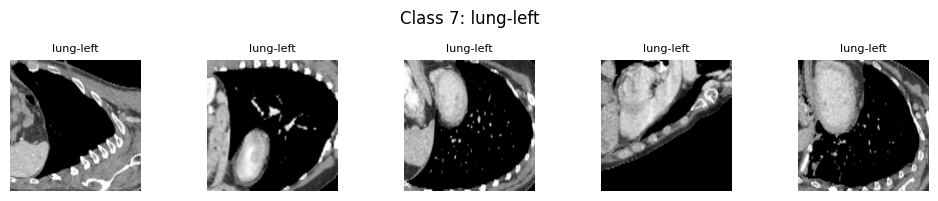

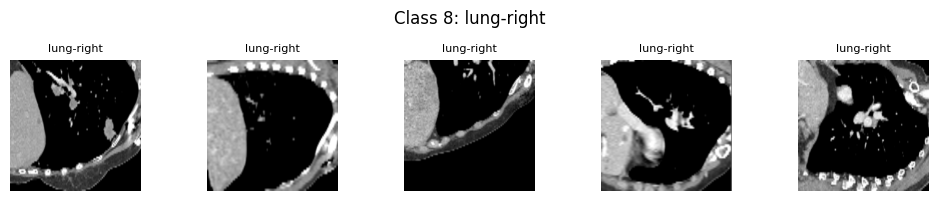

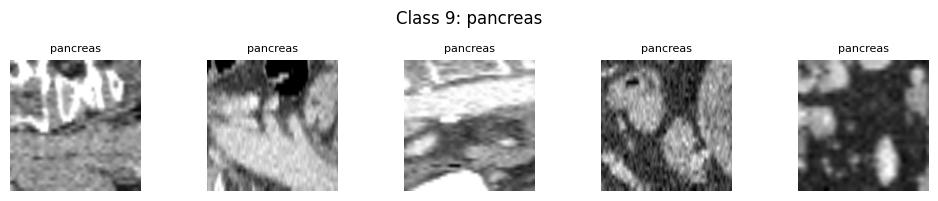

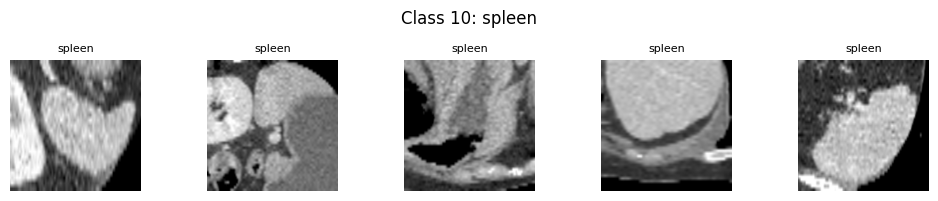

In [ ]:
show_samples_per_class(
    X_train,
    y_train,
    class_names,
    samples_per_class=5
)

# Model functions

## Evaluation

In [6]:
def evaluate_model(model, model_name, X_test, y_test, cmap):

    classes = np.arange(num_classes)

    #Mertics preparation-----------

    #Predict
    y_score = model.predict(X_test)
    y_pred = np.argmax(y_score, axis=1)

    #Basic metrics
    acc = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    #Binarise for ROC
    y_test_bin = label_binarize(y_test,  classes=classes)

    #ROC AUC
    macro_auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
    micro_auc = roc_auc_score(y_test_bin, y_score, average='micro', multi_class='ovr')

    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Balanced accuracy', 'Macro ROC-AUC', 'Micro ROC-AUC'],
        'Score': [acc, balanced_acc, macro_auc, micro_auc]
    })

    #Metrics display
    print(f"\n{model_name} metrics:")
    display(metrics_df)

    print(f'\n{model_name} classification report:')
    print(f'\n {class_report}')
    
    #Confusion matrix---------------
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6,6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
    disp.plot(ax=ax, cmap=cmap, xticks_rotation=45)
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    #ROC curve-----------------
    plt.figure(figsize=(8,6))
    roc_data = {}
    for i in range(num_classes):
        fpr, tpr, _= roc_curve(y_test_bin[:, i], y_score[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
        roc_data[i] = (fpr, tpr)
    
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title(f'{model_name} ROC curves (OVR)')
    plt.legend(loc='lower right', fontsize='small')
    plt.show()

    #ROC values---------------
    #Micro-average
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    micro_roc = (fpr_micro, tpr_micro)

    #Macro-average
    all_fpr = np.unique(np.concatenate([fpr for (fpr, _) in roc_data.values()]))
    mean_tpr = np.zeros_like(all_fpr)
    for (fpr, tpr) in roc_data.values():
        mean_tpr += np.interp(all_fpr, fpr, tpr)

    mean_tpr /= num_classes
    macro_roc = (all_fpr, mean_tpr)


    #Return results----------
    return{
        'model_name': model_name,
        'metrics': {
            'Accuracy': acc,
            'Balanced accuracy': balanced_acc,
            'Macro ROC-AUC': macro_auc,
            'Micro ROC-AUC': micro_auc
        },
        'roc_data': roc_data,
        'micro_roc': micro_roc,
        'macro_roc': macro_roc
    }
        



## Summary comparison

In [26]:
def summarise_models(results):

    #Summary table
    table = []
    for r in results:
        row = {
            'Model': r['model_name'],
            'Model Changes': r['model_changes'],
            'Accuracy': r['metrics']['Accuracy'],
            'Balanced Accuracy': r['metrics']['Balanced accuracy'],
            'Macro ROC-AUC': r['metrics']['Macro ROC-AUC'],
            'Micro ROC-AUC': r['metrics']['Micro ROC-AUC']
        }
        table.append(row)

    df = pd.DataFrame(table)
    display(df)

    #Macro ROC comparison
    plt.figure(figsize=(8,6))
    for r in results:
        fpr, tpr = r['macro_roc']
        auc_val = r['metrics']['Macro ROC-AUC']
        plt.plot(fpr, tpr, label=f"{r['model_name']} (AUC = {auc_val:.2f})")

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Macro-Average ROC Curve Comparison')
    plt.legend()
    plt.show()

    #Micro ROC comparison
    plt.figure(figsize=(8,6))
    for r in results:
        fpr, tpr = r['micro_roc']
        auc_val = r['metrics']['Micro ROC-AUC']
        plt.plot(fpr, tpr, label=f"{r['model_name']} (AUC = {auc_val:.2f})")

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Micro-Average ROC Curve Comparison')
    plt.legend()
    plt.show()

    # Accuracies comparison
    plt.figure(figsize=(10,6))

    models = [r['model_name'] for r in results]
    accuracy = [r['metrics']['Accuracy'] for r in results]
    balanced_acc = [r['metrics']['Balanced accuracy'] for r in results]

    x = np.arange(len(models))

    plt.bar(x - 0.2, accuracy, width=0.4, label='Accuracy')
    plt.bar(x + 0.2, balanced_acc, width=0.4, label='Balanced Accuracy')

    plt.xticks(x, models, rotation=45)
    plt.ylabel('Score')
    plt.title('Accuracies comparison')
    plt.legend()

    plt.show()


## Save/loading

In [8]:
#Paths--------
def model_path(model_name):
    os.makedirs('models', exist_ok=True) 
    return (f'models/{model_name}.keras')

def history_path(model_name):
    return (f'models/{model_name}_history.npy')

#Loading
def try_load_model(model_name):
    #try to load
    if os.path.exists(model_path(model_name)):
        model = load_model(model_path(model_name))
        if os.path.exists(history_path(model_name)):
            model_history = np.load((history_path(model_name)), allow_pickle=True).item()
        print(f"Loaded {model_name} from disk")
        return model, model_history
    
    #otherwise build
    else:
        print(f"No model found for {model_name}, have to build")
        return None, None

def save_model(model, model_history, model_name):
    model.save(model_path(model_name))
    np.save(history_path(model_name), model_history.history)

# Q1 (Base NN model)

##  Model definition

In [ ]:
#Build
base_NN_model = Sequential([
    Input(shape=(X_train_flat.shape[1],)),
    Dense(100, activation='relu'),
    Dense(num_classes, activation='softmax')
])

#Compilation
base_NN_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

I0000 00:00:1775752873.729713   44577 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775752873.729780   44577 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775752873.729792   44577 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775752873.937757   44577 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775752873.937823   44577 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-09

## Model training

In [12]:
base_NN_history = base_NN_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1775752900.091524   45901 service.cc:146] XLA service 0x7a87b08cc7c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775752900.092123   45901 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0
2026-04-09 16:41:40.128461: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-09 16:41:40.339195: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 91900
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feat

 34/436 [=>............................] - ETA: 1s - loss: 14.1509 - accuracy: 0.2206

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


436/436 [==============================] - 7s 12ms/step - loss: 3.1686 - accuracy: 0.2802 - val_loss: 1.9979 - val_accuracy: 0.3055
Epoch 2/10
436/436 [==============================] - 2s 4ms/step - loss: 2.0801 - accuracy: 0.3056 - val_loss: 1.9360 - val_accuracy: 0.3083
Epoch 3/10
436/436 [==============================] - 2s 4ms/step - loss: 2.0136 - accuracy: 0.3053 - val_loss: 1.8941 - val_accuracy: 0.3087
Epoch 4/10
436/436 [==============================] - 2s 4ms/step - loss: 1.9766 - accuracy: 0.3091 - val_loss: 1.9286 - val_accuracy: 0.3108
Epoch 5/10
436/436 [==============================] - 2s 4ms/step - loss: 1.9576 - accuracy: 0.3100 - val_loss: 1.9063 - val_accuracy: 0.3108
Epoch 6/10
436/436 [==============================] - 2s 4ms/step - loss: 1.9411 - accuracy: 0.3103 - val_loss: 1.9680 - val_accuracy: 0.2940
Epoch 7/10
436/436 [==============================] - 1s 3ms/step - loss: 1.9357 - accuracy: 0.3109 - val_loss: 1.9525 - val_accuracy: 0.3002
Epoch 8/10
436/4

## Model evaluation

In [12]:
evaluate_model(base_NN_model, 'Base NN', X_test_flat, y_test, 'Blues')

NameError: name 'evaluate_model' is not defined

# Q2 (NN model improvements)

In [11]:
NN_model_results = []

## Model 1 (Neuron and layer increase)

### Definition

In [10]:
NN_1_name = 'NN 1 ++(Neurons & layer)'
NN_1_desc = "Increased layers & neurons (256,128)"
NN_1_model, NN_1_history = try_load_model(NN_1_name)

#Build
if NN_1_model is None:
    NN_1_model = Sequential([
        #Input
        Input(shape=(X_train_flat.shape[1],)),
        
        #Hidden
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),

        #Output
        Dense(num_classes, activation='softmax')
    ])

    #Compilation
    NN_1_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    

I0000 00:00:1775864207.745339  771632 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775864207.745428  771632 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775864207.745445  771632 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775864208.534025  771632 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775864208.534080  771632 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-10

Loaded NN 1 ++(Neurons & layer) from disk


### Training

In [15]:
NN_1_history = NN_1_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


 14/436 [..............................] - ETA: 3s - loss: 22.0153 - accuracy: 0.1272

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


436/436 [==============================] - 7s 15ms/step - loss: 3.1874 - accuracy: 0.3688 - val_loss: 1.4721 - val_accuracy: 0.4886
Epoch 2/10
436/436 [==============================] - 2s 6ms/step - loss: 1.5627 - accuracy: 0.4877 - val_loss: 1.4378 - val_accuracy: 0.5151
Epoch 3/10
436/436 [==============================] - 2s 6ms/step - loss: 1.3334 - accuracy: 0.5329 - val_loss: 1.1914 - val_accuracy: 0.5873
Epoch 4/10
436/436 [==============================] - 2s 5ms/step - loss: 1.2234 - accuracy: 0.5679 - val_loss: 1.1721 - val_accuracy: 0.6179
Epoch 5/10
436/436 [==============================] - 2s 5ms/step - loss: 1.1090 - accuracy: 0.6049 - val_loss: 1.0701 - val_accuracy: 0.6452
Epoch 6/10
436/436 [==============================] - 2s 5ms/step - loss: 1.0292 - accuracy: 0.6299 - val_loss: 1.0151 - val_accuracy: 0.6750
Epoch 7/10
436/436 [==============================] - 2s 5ms/step - loss: 1.0142 - accuracy: 0.6323 - val_loss: 1.1009 - val_accuracy: 0.6436
Epoch 8/10
436/4

### Saving

In [17]:
save_model(NN_1_model, NN_1_history, NN_1_name)

### Evaluation

  1/276 [..............................] - ETA: 3:55

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


276/276 [==============================] - 2s 3ms/step

NN 1 ++(Neurons & layer) metrics:


,Metric,Score
0,Accuracy,0.513991
1,Balanced accuracy,0.480754
2,Macro ROC-AUC,0.877999
3,Micro ROC-AUC,0.895078



NN 1 ++(Neurons & layer) classification report:

               precision    recall  f1-score   support

           0       0.38      0.52      0.44       811
           1       0.25      0.31      0.27       439
           2       0.35      0.36      0.36       445
           3       0.88      0.34      0.49       510
           4       0.44      0.35      0.39       704
           5       0.42      0.19      0.26       693
           6       0.83      0.67      0.74      2078
           7       0.81      0.63      0.71       397
           8       0.71      0.83      0.77       439
           9       0.39      0.54      0.45      1343
          10       0.41      0.56      0.47       968

    accuracy                           0.51      8827
   macro avg       0.53      0.48      0.49      8827
weighted avg       0.56      0.51      0.52      8827



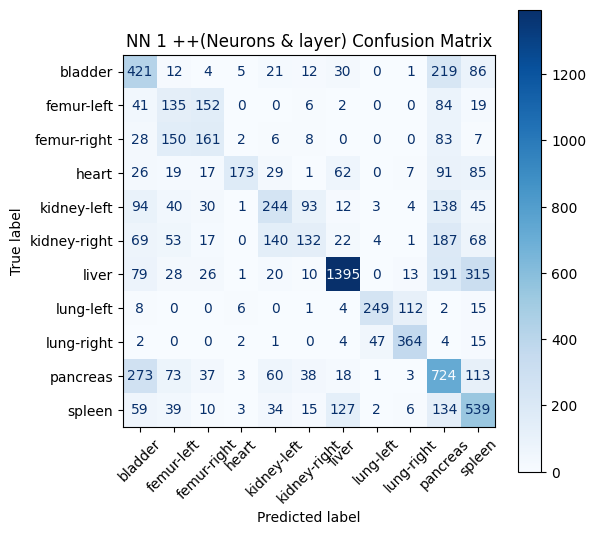

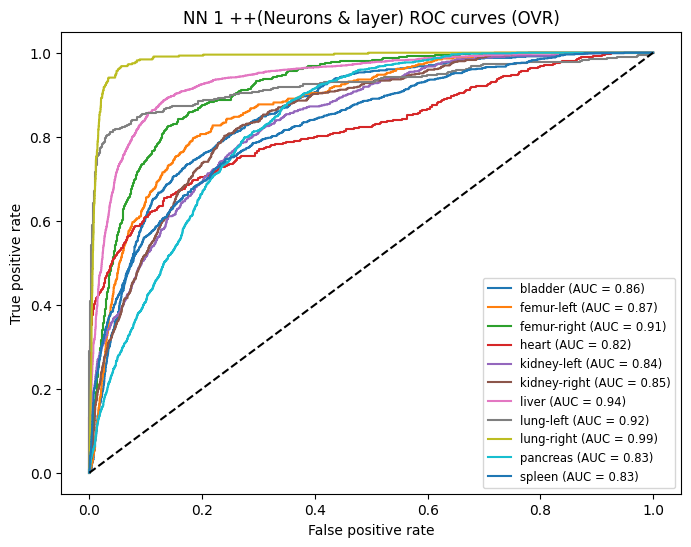

In [12]:
NN_1_results = evaluate_model(NN_1_model, NN_1_name, X_test_flat, y_test, 'Blues')
NN_1_results['model_changes'] = NN_1_desc
NN_model_results.append(NN_1_results)

## Model 2 (Class weight balancing)

### Definition

In [13]:
NN_2_name = 'NN 2 + class weights'
NN_2_desc = "Introduced class weight balancing to model 1"
NN_2_model, NN_2_history = try_load_model(NN_2_name)

#Build
if NN_2_model is None:
    NN_2_model = Sequential([
        #Input
        Input(shape=(X_train_flat.shape[1],)),
        
        #Hidden
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),

        #Output
        Dense(num_classes, activation='softmax')
    ])

    #Compilation
    NN_2_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

Loaded NN 2 + class weights from disk


In [15]:
#Class weights
y_train_flat = y_train.flatten()

balanced_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_flat
)

balanced_weights = dict(zip(classes, balanced_weights))

### Training

In [12]:
NN_2_history = NN_2_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=10,
    batch_size=32,
    class_weight= balanced_weights
)

Epoch 1/10


I0000 00:00:1775861844.969593  731600 service.cc:146] XLA service 0x7131fc3ca540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775861844.970872  731600 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0
2026-04-10 22:57:25.023164: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-10 22:57:25.247521: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 91900
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1775861845.707776  731600 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
'+ptx85' is not a rec

  4/436 [..............................] - ETA: 24s - loss: 0.9791 - accuracy: 0.6250

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


436/436 [==============================] - 19s 29ms/step - loss: 1.0813 - accuracy: 0.5766 - val_loss: 1.2583 - val_accuracy: 0.5856
Epoch 2/10
436/436 [==============================] - -1s -1319us/step - loss: 1.0411 - accuracy: 0.5991 - val_loss: 1.1322 - val_accuracy: 0.6056
Epoch 3/10
436/436 [==============================] - 2s 6ms/step - loss: 1.0067 - accuracy: 0.6051 - val_loss: 1.0649 - val_accuracy: 0.6427
Epoch 4/10
436/436 [==============================] - 2s 6ms/step - loss: 0.9806 - accuracy: 0.6128 - val_loss: 1.0459 - val_accuracy: 0.6546
Epoch 5/10
436/436 [==============================] - 2s 6ms/step - loss: 0.9768 - accuracy: 0.6188 - val_loss: 1.0586 - val_accuracy: 0.6546
Epoch 6/10
436/436 [==============================] - 2s 6ms/step - loss: 0.9683 - accuracy: 0.6253 - val_loss: 1.0976 - val_accuracy: 0.6574
Epoch 7/10
436/436 [==============================] - 3s 6ms/step - loss: 0.9502 - accuracy: 0.6305 - val_loss: 1.1385 - val_accuracy: 0.6558
Epoch 8/10

### Saving

In [14]:
save_model(NN_2_model, NN_2_history, NN_2_name)

### Evaluation

276/276 [==============================] - 1s 2ms/step

NN 2 + class weights metrics:


,Metric,Score
0,Accuracy,0.491787
1,Balanced accuracy,0.484140
2,Macro ROC-AUC,0.880797
3,Micro ROC-AUC,0.891740



NN 2 + class weights classification report:

               precision    recall  f1-score   support

           0       0.42      0.38      0.40       811
           1       0.24      0.68      0.35       439
           2       0.21      0.07      0.11       445
           3       0.43      0.68      0.52       510
           4       0.33      0.29      0.31       704
           5       0.44      0.28      0.34       693
           6       0.72      0.77      0.74      2078
           7       0.74      0.77      0.75       397
           8       0.78      0.74      0.76       439
           9       0.45      0.22      0.29      1343
          10       0.40      0.45      0.42       968

    accuracy                           0.49      8827
   macro avg       0.47      0.48      0.45      8827
weighted avg       0.50      0.49      0.48      8827



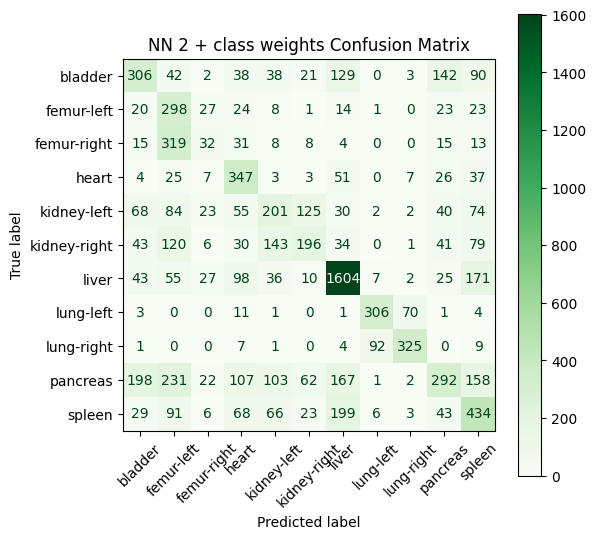

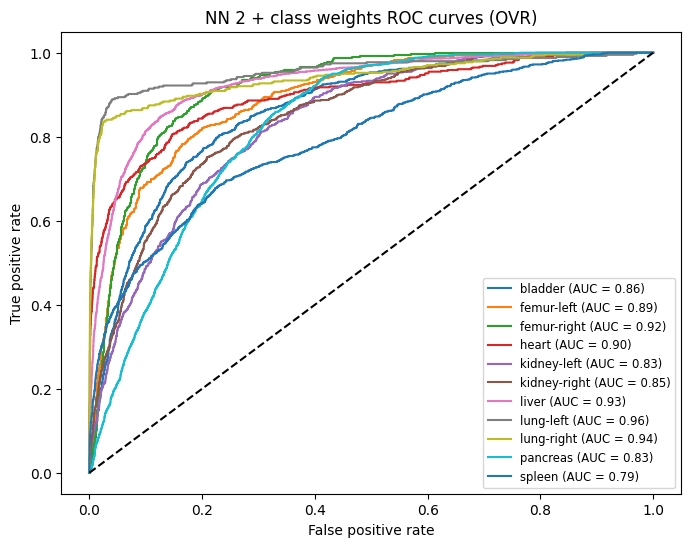

In [14]:
NN_2_results = evaluate_model(NN_2_model, NN_2_name, X_test_flat, y_test, 'Greens')
NN_2_results['model_changes'] = NN_2_desc
NN_model_results.append(NN_2_results)

## Model 3 (+Dropout)

### Definition

In [15]:
NN_3_name = 'NN 3 + dropout'
NN_3_desc = "Introduced a dropout layer to model 1"
NN_3_model, NN_3_history = try_load_model(NN_3_name)

#Build
if NN_3_model is None:
    NN_3_model = Sequential([
        #Input
        Input(shape=(X_train_flat.shape[1],)),
        
        #Hidden
        Dense(256, activation='relu'),
        Dropout(0.2),
        Dense(128, activation='relu'),

        #Output
        Dense(num_classes, activation='softmax')
    ])

    #Compilation
    NN_3_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

Loaded NN 3 + dropout from disk


### Training

In [10]:
NN_3_history = NN_3_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  4/436 [..............................] - ETA: 9s - loss: 1.8823 - accuracy: 0.2969   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


436/436 [==============================] - 9s 13ms/step - loss: 1.8118 - accuracy: 0.3412 - val_loss: 1.6825 - val_accuracy: 0.4042
Epoch 2/10
436/436 [==============================] - 2s 5ms/step - loss: 1.7277 - accuracy: 0.3722 - val_loss: 1.7042 - val_accuracy: 0.3736
Epoch 3/10
436/436 [==============================] - 2s 5ms/step - loss: 1.7129 - accuracy: 0.3755 - val_loss: 1.7625 - val_accuracy: 0.3830
Epoch 4/10
436/436 [==============================] - 2s 5ms/step - loss: 1.7209 - accuracy: 0.3760 - val_loss: 1.6625 - val_accuracy: 0.3960
Epoch 5/10
436/436 [==============================] - 2s 5ms/step - loss: 1.7061 - accuracy: 0.3778 - val_loss: 1.5734 - val_accuracy: 0.4042
Epoch 6/10
436/436 [==============================] - 2s 5ms/step - loss: 1.6873 - accuracy: 0.3836 - val_loss: 1.5974 - val_accuracy: 0.4172
Epoch 7/10
436/436 [==============================] - 2s 5ms/step - loss: 1.6861 - accuracy: 0.3851 - val_loss: 1.5703 - val_accuracy: 0.4152
Epoch 8/10
436/4

### Saving

In [12]:
save_model(NN_3_model, NN_3_history, NN_3_name)

### Evaluation

276/276 [==============================] - 1s 2ms/step

NN 3 + dropout metrics:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Score
0,Accuracy,0.355160
1,Balanced accuracy,0.277342
2,Macro ROC-AUC,0.726100
3,Micro ROC-AUC,0.802393



NN 3 + dropout classification report:

               precision    recall  f1-score   support

           0       0.24      0.02      0.04       811
           1       0.00      0.00      0.00       439
           2       0.73      0.02      0.05       445
           3       0.81      0.16      0.27       510
           4       0.00      0.00      0.00       704
           5       0.00      0.00      0.00       693
           6       0.66      0.57      0.61      2078
           7       0.60      0.69      0.64       397
           8       0.74      0.62      0.67       439
           9       0.22      0.97      0.35      1343
          10       0.07      0.00      0.00       968

    accuracy                           0.36      8827
   macro avg       0.37      0.28      0.24      8827
weighted avg       0.37      0.36      0.28      8827



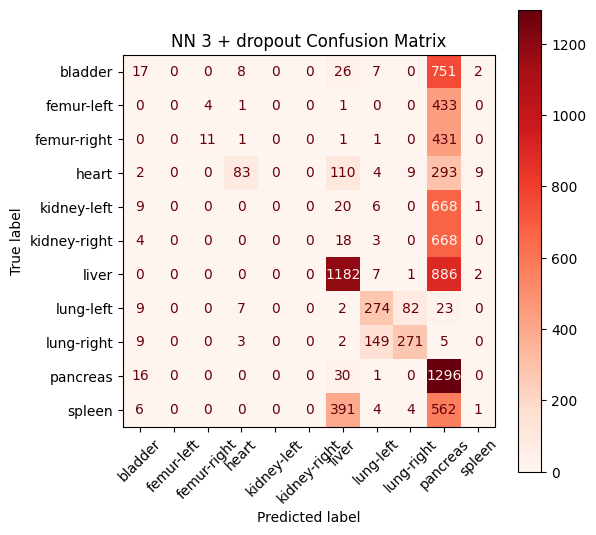

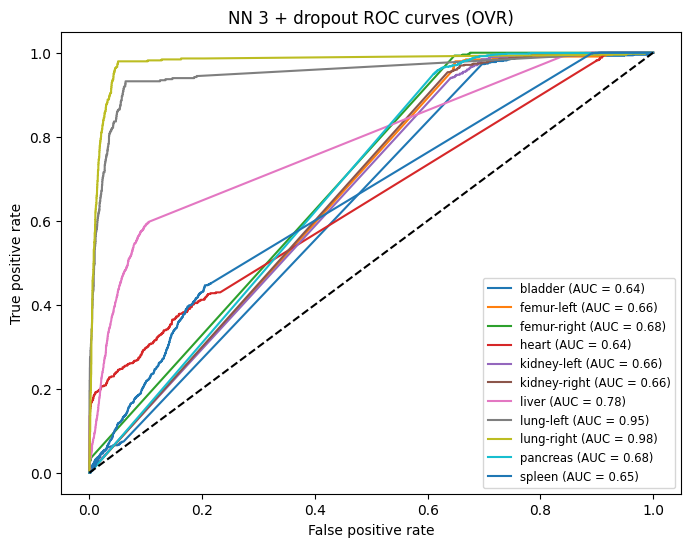

In [16]:
NN_3_results = evaluate_model(NN_3_model, NN_3_name, X_test_flat, y_test, 'Reds')
NN_3_results['model_changes'] = NN_3_desc
NN_model_results.append(NN_3_results)

## Model 4 --(Learning rate)

### Definition

In [17]:
NN_4_name = 'NN 4 --learn rate'
NN_4_desc = "Decreased the learning rate of model 2"
NN_4_model, NN_4_history = try_load_model(NN_4_name)

#Build
if NN_4_model is None:
    NN_4_model = Sequential([
        #Input
        Input(shape=(X_train_flat.shape[1],)),
        
        #Hidden
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),

        #Output
        Dense(num_classes, activation='softmax')
    ])

    #Compilation
    NN_4_model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

Loaded NN 4 --learn rate from disk


### Training

In [13]:
NN_4_history = NN_4_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=10,
    batch_size=32,
    class_weight= balanced_weights
)

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1775861154.317027  718540 service.cc:146] XLA service 0x7e0c743d6840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775861154.317405  718540 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0
2026-04-10 22:45:54.352522: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-10 22:45:54.584265: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 91900
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feat

  8/436 [..............................] - ETA: 3s - loss: 0.9138 - accuracy: 0.6680   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


436/436 [==============================] - 11s 21ms/step - loss: 0.8928 - accuracy: 0.6525 - val_loss: 1.0717 - val_accuracy: 0.6358
Epoch 2/10
436/436 [==============================] - 3s 6ms/step - loss: 0.8907 - accuracy: 0.6532 - val_loss: 1.1574 - val_accuracy: 0.6603
Epoch 3/10
436/436 [==============================] - 3s 6ms/step - loss: 0.8735 - accuracy: 0.6654 - val_loss: 1.2344 - val_accuracy: 0.6480
Epoch 4/10
436/436 [==============================] - 3s 6ms/step - loss: 0.8307 - accuracy: 0.6811 - val_loss: 1.4471 - val_accuracy: 0.6321
Epoch 5/10
436/436 [==============================] - 2s 6ms/step - loss: 0.8141 - accuracy: 0.6845 - val_loss: 1.0597 - val_accuracy: 0.6900
Epoch 6/10
436/436 [==============================] - 2s 6ms/step - loss: 0.8044 - accuracy: 0.6960 - val_loss: 1.4188 - val_accuracy: 0.6517
Epoch 7/10
436/436 [==============================] - 2s 6ms/step - loss: 0.7714 - accuracy: 0.7061 - val_loss: 1.1951 - val_accuracy: 0.6619
Epoch 8/10
436/

### Saving

In [15]:
save_model(NN_4_model, NN_4_history, NN_4_name)

### Evaluation

276/276 [==============================] - 1s 2ms/step

NN 4 --learn rate metrics:


,Metric,Score
0,Accuracy,0.488048
1,Balanced accuracy,0.501650
2,Macro ROC-AUC,0.886954
3,Micro ROC-AUC,0.888933



NN 4 --learn rate classification report:

               precision    recall  f1-score   support

           0       0.52      0.47      0.50       811
           1       0.25      0.56      0.35       439
           2       0.18      0.22      0.20       445
           3       0.45      0.63      0.52       510
           4       0.32      0.46      0.37       704
           5       0.40      0.36      0.38       693
           6       0.85      0.58      0.69      2078
           7       0.71      0.78      0.74       397
           8       0.81      0.66      0.73       439
           9       0.46      0.29      0.35      1343
          10       0.42      0.50      0.46       968

    accuracy                           0.49      8827
   macro avg       0.49      0.50      0.48      8827
weighted avg       0.54      0.49      0.50      8827



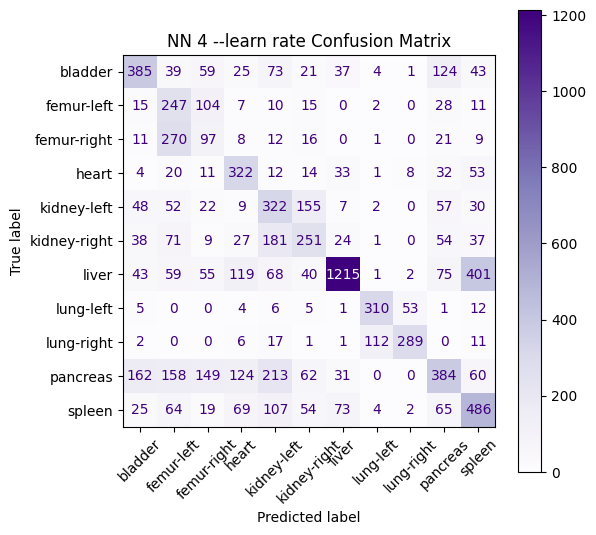

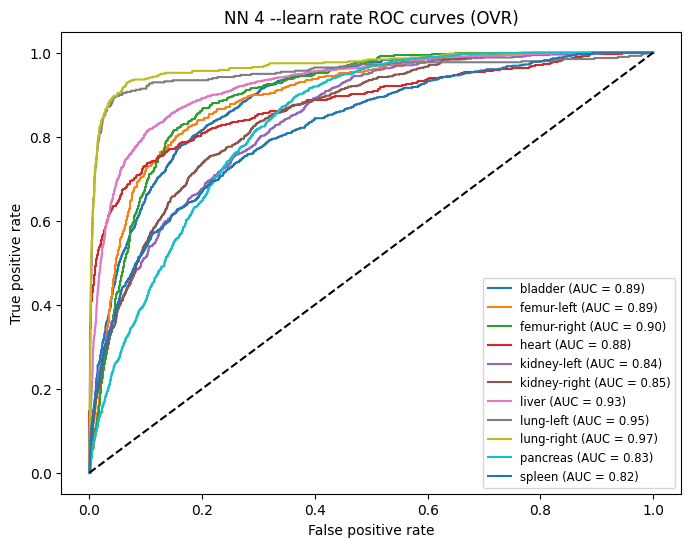

In [18]:
NN_4_results = evaluate_model(NN_4_model, NN_4_name, X_test_flat, y_test, 'Purples')
NN_4_results['model_changes'] = NN_4_desc
NN_model_results.append(NN_4_results)

## Model 5 (Depth increase)

### Definition

In [19]:
NN_5_name = 'NN 5 + extra depth'
NN_5_desc = "Increased the layer depth of model 4 (256, 128, 64)"
NN_5_model, NN_5_history = try_load_model(NN_5_name)

#Build
if NN_5_model is None:
    NN_5_model = Sequential([
        #Input
        Input(shape=(X_train_flat.shape[1],)),
        
        #Hidden
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),

        #Output
        Dense(num_classes, activation='softmax')
    ])

    #Compilation
    NN_5_model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

Loaded NN 5 + extra depth from disk


### Training

In [15]:
NN_5_history = NN_5_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=10,
    batch_size=32,
    class_weight= balanced_weights
)

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1775860477.441496  706882 service.cc:146] XLA service 0x70707e1b5810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775860477.442331  706882 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0
2026-04-10 22:34:37.485898: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-10 22:34:37.710928: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 91900
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feat

 24/436 [>.............................] - ETA: 2s - loss: 6.1867 - accuracy: 0.0977

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


436/436 [==============================] - 10s 23ms/step - loss: 2.2762 - accuracy: 0.2878 - val_loss: 1.2972 - val_accuracy: 0.4992
Epoch 2/10
436/436 [==============================] - 3s 6ms/step - loss: 1.5053 - accuracy: 0.4363 - val_loss: 1.3111 - val_accuracy: 0.4572
Epoch 3/10
436/436 [==============================] - 3s 6ms/step - loss: 1.3527 - accuracy: 0.4872 - val_loss: 1.2510 - val_accuracy: 0.5685
Epoch 4/10
436/436 [==============================] - 3s 6ms/step - loss: 1.2586 - accuracy: 0.5166 - val_loss: 0.9781 - val_accuracy: 0.6737
Epoch 5/10
436/436 [==============================] - 3s 6ms/step - loss: 1.1427 - accuracy: 0.5607 - val_loss: 1.1341 - val_accuracy: 0.5844
Epoch 6/10
436/436 [==============================] - 3s 6ms/step - loss: 1.0684 - accuracy: 0.5835 - val_loss: 1.0257 - val_accuracy: 0.6260
Epoch 7/10
436/436 [==============================] - 3s 6ms/step - loss: 1.0260 - accuracy: 0.5996 - val_loss: 1.1003 - val_accuracy: 0.6281
Epoch 8/10
436/

### Saving

In [16]:
save_model(NN_5_model, NN_5_history, NN_5_name)

### Evaluation

276/276 [==============================] - 1s 2ms/step

NN 5 + extra depth metrics:


,Metric,Score
0,Accuracy,0.459273
1,Balanced accuracy,0.454629
2,Macro ROC-AUC,0.865817
3,Micro ROC-AUC,0.880131



NN 5 + extra depth classification report:

               precision    recall  f1-score   support

           0       0.29      0.66      0.41       811
           1       0.28      0.08      0.12       439
           2       0.33      0.26      0.29       445
           3       0.58      0.55      0.57       510
           4       0.31      0.34      0.33       704
           5       0.23      0.32      0.27       693
           6       0.83      0.55      0.66      2078
           7       0.68      0.78      0.73       397
           8       0.76      0.67      0.71       439
           9       0.38      0.30      0.34      1343
          10       0.45      0.49      0.47       968

    accuracy                           0.46      8827
   macro avg       0.47      0.45      0.44      8827
weighted avg       0.51      0.46      0.46      8827



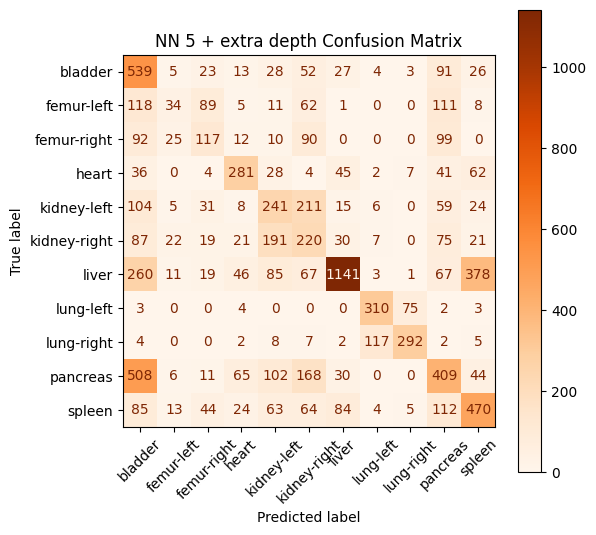

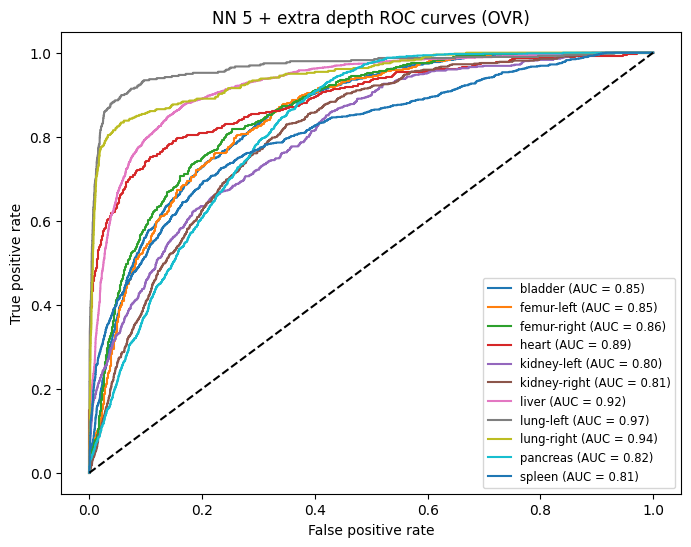

In [20]:
NN_5_results = evaluate_model(NN_5_model, NN_5_name, X_test_flat, y_test, 'Oranges')
NN_5_results['model_changes'] = NN_5_desc
NN_model_results.append(NN_5_results)

## Model comparisons

,Model,Model Changes,Accuracy,Balanced Accuracy,Macro ROC-AUC,Micro ROC-AUC
0,NN 1 ++(Neurons & layer),"Increased layers & neurons (256,128)",0.513991,0.480754,0.877999,0.895078
1,NN 2 + class weights,Introduced class weight balancing to model 1,0.491787,0.484140,0.880797,0.891740
2,NN 3 + dropout,Introduced a dropout layer to model 1,0.355160,0.277342,0.726100,0.802393
3,NN 4 --learn rate,Decreased the learning rate of model 2,0.488048,0.501650,0.886954,0.888933
4,NN 5 + extra depth,"Increased the layer depth of model 4 (256, 128...",0.459273,0.454629,0.865817,0.880131


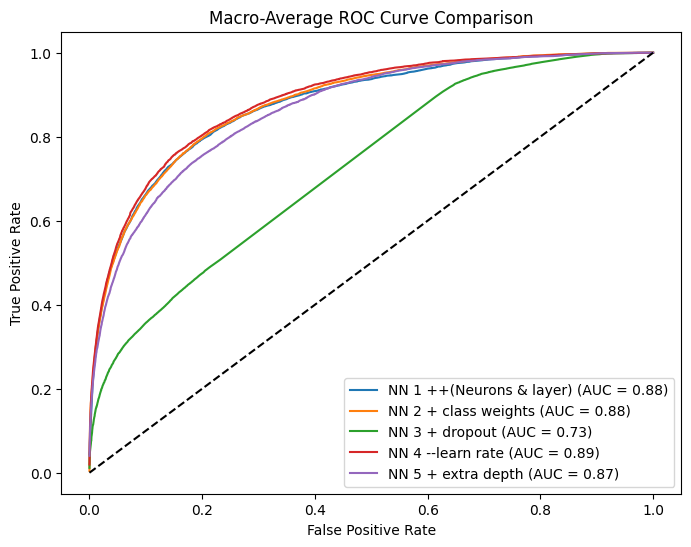

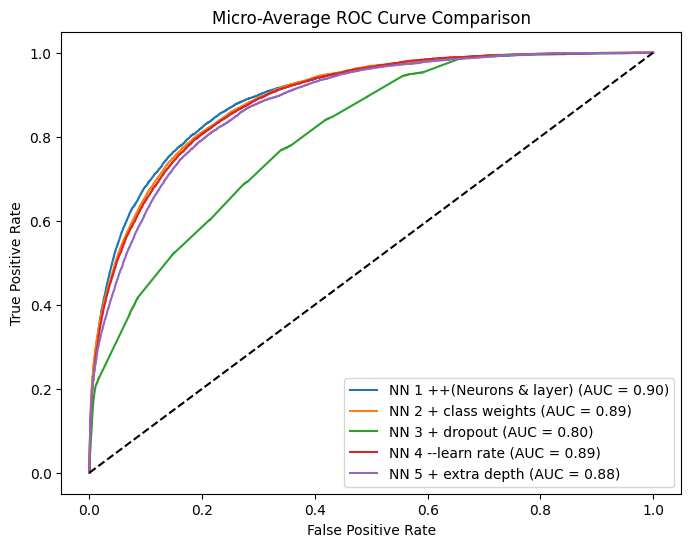

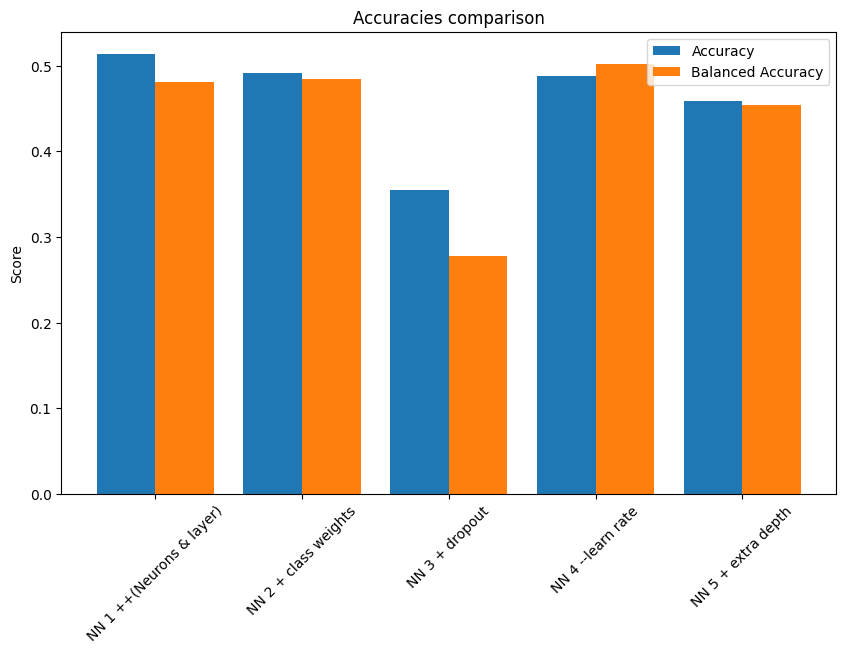

In [27]:
summarise_models(NN_model_results)

## Discussion
lala

# Q3

In [ ]:
# add code for Q3

## Q4

In [ ]:
# add code for Q4

In [ ]:
# add discussion for Q4

## Q5

In [ ]:
# add code for Q5

In [ ]:
# add discussion for Q5

## Q6

In [ ]:
# add code for Q6

In [ ]:
# add discussion for Q6

## Q7

In [ ]:
# add code for Q7

In [ ]:
# add discussion for Q7

# References (text)

List any references you may have used in your document before, using one of the established referencing system (e.g. IEEE, Harvard, etc).